In [9]:
import pandas as pd

sales = pd.read_csv(r"C:\Users\Kevin\Desktop\transactions.csv", parse_dates=["date"])

array([[<Axes: title={'center': 'Pood 1'}, xlabel='date'>,
        <Axes: title={'center': 'Pood 2'}, xlabel='date'>],
       [<Axes: title={'center': 'Pood 3'}, xlabel='date'>,
        <Axes: title={'center': 'Pood 4'}, xlabel='date'>]], dtype=object)

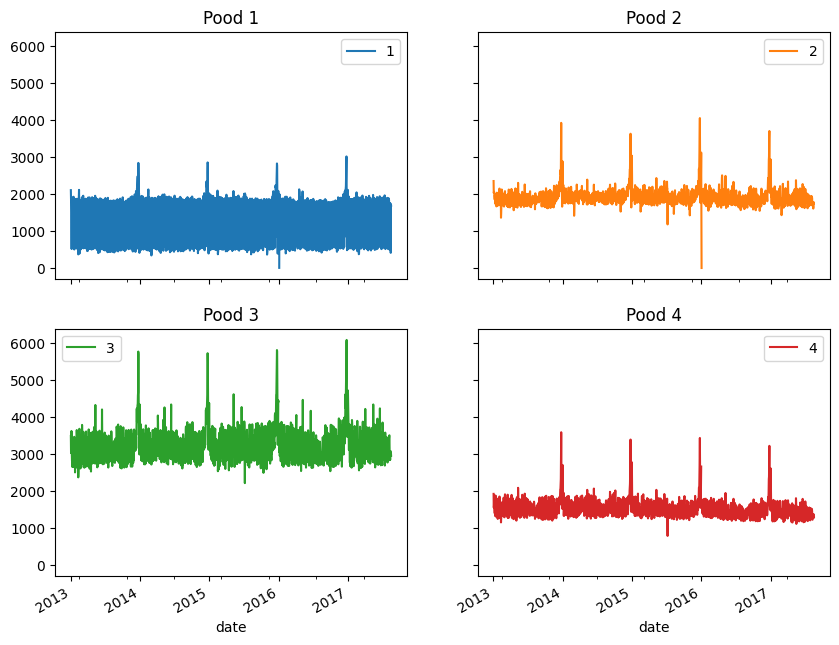

In [10]:
store1234 = (
    sales
    .query("store_nbr in [1, 2, 3, 4]")
    .pivot(index="date", columns="store_nbr", values="transactions")
)

# 2. Samm: Nüüd võid tüüpi kontrollida (kuigi see on juba datetime), 
# aga kasuta pigem seda kindlamat meetodit:
store1234.index = pd.to_datetime(store1234.index)

# 3. Samm: Joonista alles nüüd
store1234.plot(
    subplots=True,
    layout=(2, 2),
    figsize=(10, 8),
    sharey=True,
    title=["Pood 1", "Pood 2", "Pood 3", "Pood 4"]
)

In [11]:
store1234.index = store1234.index.astype("datetime64[ns]")
store1234

store_nbr,1,2,3,4
date,,,,
2013-01-02,2111.0,2358.0,3487.0,1922.0
2013-01-03,1833.0,2033.0,3026.0,1551.0
2013-01-04,1863.0,2066.0,3188.0,1596.0
2013-01-05,1509.0,2062.0,3623.0,1825.0
2013-01-06,520.0,1992.0,3590.0,1891.0
...,...,...,...,...
2017-08-11,570.0,1698.0,2991.0,1301.0
2017-08-12,1004.0,1613.0,3070.0,1304.0
2017-08-13,416.0,1658.0,3075.0,1378.0


In [12]:
store1234_monthly = store1234.groupby(store1234.index.month).sum()
store1234_monthly

store_nbr,1,2,3,4
date,,,,
1,229203.0,284134.0,463260.0,222075.0
2,209400.0,265922.0,437238.0,209211.0
3,232178.0,293076.0,487224.0,231837.0
4,229081.0,287325.0,478308.0,223928.0
5,231160.0,293588.0,491961.0,228753.0
6,231514.0,284835.0,474668.0,222678.0
7,236032.0,288783.0,484698.0,224327.0
8,202821.0,255475.0,431752.0,200100.0
9,182035.0,228658.0,379101.0,178172.0


<Axes: ylabel='date'>

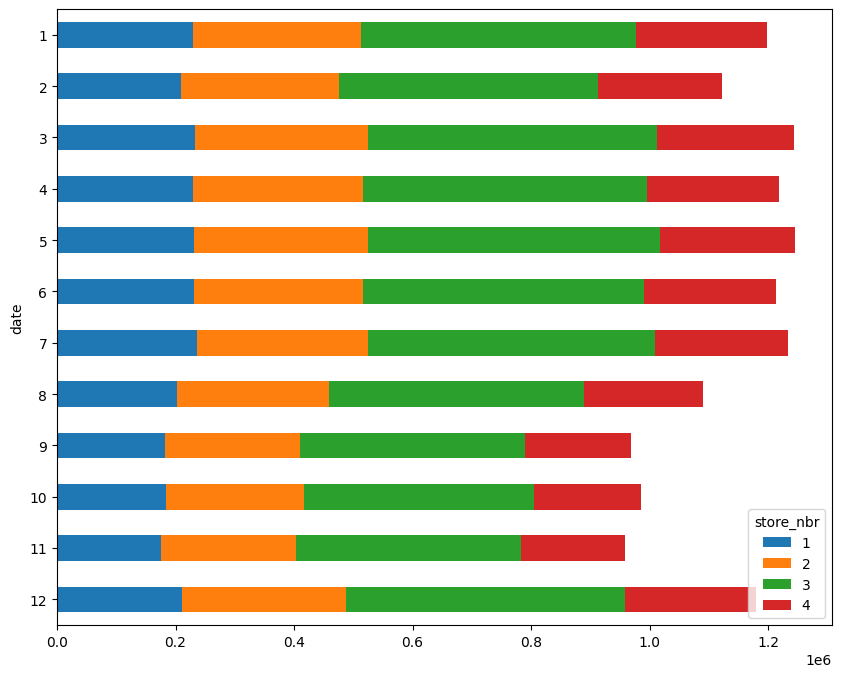

In [13]:
(
    store1234_monthly
    .sort_index(ascending=False) # Sorteerime kuud nii, et 12 on ülal
    .plot.barh(
        stacked=True,           # Paneb poed üksteise otsa
        figsize=(10, 8)
    )
)